# Polar Decoder v2 — Per-Angle Attention + Fourier Regularization

**Clean architecture:**
- 128 radii (finer angular resolution)
- Per-angle cross-attention decoder (each radius has its own query)
- Fourier contour descriptor (smoothness regularizer)
- Multi-centroid classification (concavity detection)
- MSE loss only (stable, no conflicting gradients)
- Evaluation: IoU against raw binary mask (honest metric)
- Qualitative: 2 images per real dataset

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'einops'])

import os, json, math, random, glob as _glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

assert torch.cuda.is_available(), 'No GPU! Select T4 x2 in Kaggle Settings.'
_cc = torch.cuda.get_device_capability(0)
assert _cc[0]*10+_cc[1] >= 70, f'GPU sm_{_cc[0]}{_cc[1]} too old. Select T4 x2.'
device = torch.device('cuda')
print(f'GPU: {torch.cuda.get_device_name(0)} | PyTorch: {torch.__version__}')

NUM_RADII   = 128
IMAGE_SIZE  = 256
D_MODEL     = 256
BATCH       = 6
MAX_EPOCHS  = 50
LR          = 1e-4

for d in ['results/polar_v2', 'figures/polar_v2']:
    Path(d).mkdir(parents=True, exist_ok=True)
print('Setup complete.')

GPU: Tesla T4 | PyTorch: 2.10.0+cu128
Setup complete.


## 1. Data Loading

In [2]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

_candidates = [
    Path('/kaggle/input/datasets/dianisay/wound-datasets/Datasets'),
    Path('/kaggle/input/wound-datasets/Datasets'),
    Path('/kaggle/input/datasets/dianisay/wound-datasets'),
    Path('/kaggle/input/wound-datasets'),
    Path('data/wound-datasets'),
]
BASE_PATH = next((p for p in _candidates if p.exists()), _candidates[0])
print(f'BASE_PATH: {BASE_PATH} (exists={BASE_PATH.exists()})')

WOUND_DATASETS = [
    {'name': 'FUSeg', 'root': BASE_PATH / 'Foot Ulcer Segmentation Challenge',
     'splits': {'train': ('train/images', 'train/labels'),
                'val': ('validation/images', 'validation/labels'),
                'test': ('test/images', None)}},
    {'name': 'Medetec', 'root': BASE_PATH / 'Medetec_foot_ulcer_224',
     'splits': {'train': ('train/images', 'train/labels'),
                'test': ('test/images', 'test/labels')}},
    {'name': 'AZH', 'root': BASE_PATH / 'wound_dataset' / 'azh_wound_care_center_dataset_patches',
     'splits': {'train': ('train/images', 'train/labels'),
                'test': ('test/images', 'test/labels')}},
]

def load_wound_pairs(datasets, split='train'):
    pairs = []
    for ds in datasets:
        root = ds['root']
        if not root.exists(): continue
        if split in ds['splits']:
            img_rel, lbl_rel = ds['splits'][split]
        elif split == 'val' and 'test' in ds['splits']:
            img_rel, lbl_rel = ds['splits']['test']
        else: continue
        img_dir = root / img_rel
        lbl_dir = root / lbl_rel if lbl_rel else None
        if not img_dir.exists(): continue
        imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])
        if lbl_dir and lbl_dir.exists():
            lbl_files = {p.stem.lower(): p for p in lbl_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS}
            for img_p in imgs:
                mask_p = lbl_files.get(img_p.stem.lower())
                if mask_p:
                    pairs.append((img_p, mask_p, ds['name']))
    return pairs

train_pairs = load_wound_pairs(WOUND_DATASETS, 'train')
val_pairs   = load_wound_pairs(WOUND_DATASETS, 'val')
test_pairs  = load_wound_pairs(WOUND_DATASETS, 'test')
USE_REAL_DATA = len(train_pairs) > 0
print(f'Real data: train={len(train_pairs)}, val={len(val_pairs)}, test={len(test_pairs)}')

BASE_PATH: /kaggle/input/datasets/dianisay/wound-datasets/Datasets (exists=True)
Real data: train=1793, val=486, test=286


In [3]:
def mask_to_polar(mask, num_radii=NUM_RADII, image_size=IMAGE_SIZE):
    if mask.max() <= 1:
        mask_bin = (mask > 0).astype(np.uint8) * 255
    else:
        mask_bin = (mask > 127).astype(np.uint8) * 255
    ys, xs = np.where(mask_bin > 0)
    if len(xs) < 50:
        return None
    cx = float(xs.mean()) / mask_bin.shape[1]
    cy = float(ys.mean()) / mask_bin.shape[0]
    cpx, cpy = int(cx * mask_bin.shape[1]), int(cy * mask_bin.shape[0])
    cpx = np.clip(cpx, 0, mask_bin.shape[1]-1)
    cpy = np.clip(cpy, 0, mask_bin.shape[0]-1)
    if mask_bin[cpy, cpx] == 0:
        cx = float(np.median(xs)) / mask_bin.shape[1]
        cy = float(np.median(ys)) / mask_bin.shape[0]
    angles = np.linspace(0, 2*np.pi, num_radii, endpoint=False)
    radii = np.zeros(num_radii, dtype=np.float32)
    cxp, cyp = cx * mask_bin.shape[1], cy * mask_bin.shape[0]
    max_r = max(mask_bin.shape) * 0.7
    for i, ang in enumerate(angles):
        dx, dy = np.cos(ang), np.sin(ang)
        for step in range(1, int(max_r)):
            px = int(cxp + dx * step)
            py = int(cyp + dy * step)
            if px < 0 or px >= mask_bin.shape[1] or py < 0 or py >= mask_bin.shape[0]:
                radii[i] = step / max(mask_bin.shape); break
            if mask_bin[py, px] == 0:
                radii[i] = step / max(mask_bin.shape); break
        else:
            radii[i] = max_r / max(mask_bin.shape)
    min_radius = 3.0 / max(mask_bin.shape)
    if (radii > min_radius).sum() < num_radii * 0.5:
        return None
    radii = np.maximum(radii, min_radius)
    points = np.stack([cx + radii*np.cos(angles), cy + radii*np.sin(angles)], 1).astype(np.float32)
    return {'centroid': np.array([cx, cy], dtype=np.float32), 'radii': radii, 'points': points}

print('mask_to_polar defined.')

mask_to_polar defined.


In [4]:
class WoundDatasetV2(Dataset):
    """Pre-validates all samples at init. No recursive __getitem__."""
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, real_pairs=None, synthetic_dir=None,
                 image_size=IMAGE_SIZE, num_radii=NUM_RADII, augment=True):
        self.image_size = image_size
        self.num_radii  = num_radii
        self.augment    = augment
        self.normalize  = T.Normalize(self.MEAN, self.STD)
        self.valid_samples = []
        n_skipped = 0
        if real_pairs:
            for item in real_pairs:
                img_path, mask_path = item[0], item[1]
                ds_name = item[2] if len(item) > 2 else 'unknown'
                try:
                    mask = np.array(Image.open(mask_path).convert('L').resize(
                        (image_size, image_size), Image.NEAREST))
                    label = mask_to_polar(mask, num_radii, image_size)
                    if label is not None:
                        self.valid_samples.append({'img_path': img_path, 'mask_path': mask_path,
                            'label': label, 'ds_name': ds_name})
                    else: n_skipped += 1
                except: n_skipped += 1
        if synthetic_dir and Path(synthetic_dir, 'labels.npz').exists():
            data = np.load(Path(synthetic_dir) / 'labels.npz')
            imgs_dir = Path(synthetic_dir) / 'images'
            for i in range(len(data['centroids'])):
                lbl = {'centroid': data['centroids'][i].astype(np.float32),
                       'radii': data['radii'][i].astype(np.float32),
                       'points': data['points'][i].astype(np.float32)}
                self.valid_samples.append({'img_path': imgs_dir / f'{i:05d}.png',
                    'mask_path': None, 'label': lbl, 'ds_name': 'synthetic'})
        if n_skipped > 0: print(f'  Skipped {n_skipped} invalid masks.')
        print(f'  Valid samples: {len(self.valid_samples)}')

    def __len__(self): return len(self.valid_samples)

    def __getitem__(self, idx):
        sample = self.valid_samples[idx]
        img_pil = Image.open(sample['img_path']).convert('RGB').resize(
            (self.image_size, self.image_size), Image.BILINEAR)
        img_np = np.array(img_pil)
        label = {k: v.copy() if isinstance(v, np.ndarray) else v for k, v in sample['label'].items()}
        raw_mask = None
        if sample['mask_path'] is not None:
            raw_mask = np.array(Image.open(sample['mask_path']).convert('L').resize(
                (self.image_size, self.image_size), Image.NEAREST))
            if raw_mask.max() <= 1: raw_mask = raw_mask * 255
        if self.augment:
            img_np, label = self._augment(img_np, label)
        img_t = torch.from_numpy(img_np.copy()).permute(2,0,1).float() / 255.0
        img_t = self.normalize(img_t)
        mask_t = torch.from_numpy(raw_mask).float()/255.0 if raw_mask is not None else torch.zeros(self.image_size, self.image_size)
        return {'image': img_t, 'centroid': torch.tensor(label['centroid']),
                'radii': torch.tensor(label['radii']), 'points': torch.tensor(label['points']),
                'raw_mask': mask_t, 'ds_name': sample['ds_name'],
                'has_mask': torch.tensor(1.0 if raw_mask is not None else 0.0)}

    def _augment(self, img_np, label):
        N = self.num_radii
        angles = np.linspace(0, 2*np.pi, N, endpoint=False)
        if random.random() > 0.5:
            img_np = img_np[:, ::-1].copy()
            label['centroid'][0] = 1 - label['centroid'][0]
            label['radii'] = np.roll(label['radii'][::-1], N//2 + 1).copy()
        if random.random() > 0.5:
            img_np = img_np[::-1, :].copy()
            label['centroid'][1] = 1 - label['centroid'][1]
            label['radii'] = label['radii'][::-1].copy()
        if random.random() > 0.3:
            rot_deg = random.uniform(-30, 30)
            rot_rad = np.radians(rot_deg)
            H, W = img_np.shape[:2]
            M = cv2.getRotationMatrix2D((W/2, H/2), rot_deg, 1.0)
            img_np = cv2.warpAffine(img_np, M, (W, H), borderMode=cv2.BORDER_REFLECT_101)
            cx, cy = label['centroid'][0]-0.5, label['centroid'][1]-0.5
            cos_r, sin_r = np.cos(-rot_rad), np.sin(-rot_rad)
            label['centroid'][0] = cx*cos_r - cy*sin_r + 0.5
            label['centroid'][1] = cx*sin_r + cy*cos_r + 0.5
            shift = int(round(rot_rad / (2*np.pi) * N)) % N
            label['radii'] = np.roll(label['radii'], shift).copy()
        if random.random() > 0.5:
            label['radii'] = (label['radii'] * random.uniform(0.85, 1.15)).astype(np.float32)
        label['points'] = np.stack([label['centroid'][0] + label['radii']*np.cos(angles),
                                    label['centroid'][1] + label['radii']*np.sin(angles)], 1).astype(np.float32)
        hsv = cv2.cvtColor(img_np, cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:,:,0] = (hsv[:,:,0] + random.uniform(-15, 15)) % 180
        hsv[:,:,1] = np.clip(hsv[:,:,1] * random.uniform(0.7, 1.4), 0, 255)
        hsv[:,:,2] = np.clip(hsv[:,:,2] * random.uniform(0.6, 1.4), 0, 255)
        img_np = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
        if random.random() > 0.5:
            img_np = np.clip(img_np.astype(np.float32)*random.uniform(0.7,1.3)+random.uniform(-20,20), 0, 255).astype(np.uint8)
        if random.random() > 0.5:
            img_np = np.clip(img_np.astype(np.float32)+np.random.normal(0,random.uniform(3,12),img_np.shape), 0, 255).astype(np.uint8)
        return img_np, label

print('WoundDatasetV2 defined.')

WoundDatasetV2 defined.


In [5]:
def generate_star_convex_wound(image_size=IMAGE_SIZE, num_radii=NUM_RADII, rng=None):
    if rng is None: rng = np.random
    H = W = image_size
    cx, cy = rng.uniform(0.35, 0.65), rng.uniform(0.35, 0.65)
    angles = np.linspace(0, 2*np.pi, num_radii, endpoint=False)
    base_r = rng.uniform(0.12, 0.28)
    r = np.ones(num_radii) * base_r
    for k in range(1, rng.randint(3,8)+1):
        r += rng.uniform(0, base_r*0.3/k) * np.cos(k*angles + rng.uniform(0, 2*np.pi))
    r = np.clip(r, 0.04, 0.45)
    pts_x = np.clip(cx + r*np.cos(angles), 0.01, 0.99)
    pts_y = np.clip(cy + r*np.sin(angles), 0.01, 0.99)
    skin_rgb = (int(rng.uniform(150,230)), int(rng.uniform(100,180)), int(rng.uniform(80,150)))
    img = np.clip(np.array([[[skin_rgb[0], skin_rgb[1], skin_rgb[2]]]], dtype=np.int16)
                  + rng.randint(-15,15,(H,W,3)).astype(np.int16), 0, 255).astype(np.uint8)
    mask = np.zeros((H,W), dtype=np.uint8)
    poly = np.stack([pts_x*W, pts_y*H], axis=1).astype(np.int32)
    cv2.fillPoly(mask, [poly], 255)
    wound_rgb = (int(rng.uniform(140,190)), int(rng.uniform(50,90)), int(rng.uniform(60,100)))
    img[mask>0] = wound_rgb
    img = cv2.GaussianBlur(img, (5,5), 1.5)
    return {'image': img, 'centroid': np.array([cx,cy], dtype=np.float32),
            'radii': r.astype(np.float32), 'points': np.stack([pts_x, pts_y], 1).astype(np.float32)}

def generate_dataset(out_dir, num_samples=2000, seed=42):
    rng = np.random.RandomState(seed)
    Path(out_dir,'images').mkdir(parents=True, exist_ok=True)
    centroids, radii_all, points_all = [], [], []
    for i in range(num_samples):
        s = generate_star_convex_wound(num_radii=NUM_RADII, rng=rng)
        Image.fromarray(s['image']).save(Path(out_dir,'images',f'{i:05d}.png'))
        centroids.append(s['centroid']); radii_all.append(s['radii']); points_all.append(s['points'])
    np.savez(Path(out_dir,'labels.npz'), centroids=np.array(centroids),
             radii=np.array(radii_all), points=np.array(points_all))
    print(f'Generated {num_samples} synthetic samples.')

SYNTHETIC_DIR = 'data/synthetic_128'
if not Path(SYNTHETIC_DIR, 'labels.npz').exists():
    generate_dataset(SYNTHETIC_DIR, num_samples=2000, seed=SEED)
else:
    print('Synthetic dataset exists.')

if USE_REAL_DATA:
    train_ds = WoundDatasetV2(real_pairs=train_pairs, synthetic_dir=SYNTHETIC_DIR, augment=True)
    val_ds = WoundDatasetV2(real_pairs=val_pairs if val_pairs else None,
                            synthetic_dir=SYNTHETIC_DIR if not val_pairs else None, augment=False)
    test_ds = WoundDatasetV2(real_pairs=test_pairs if test_pairs else None,
                             synthetic_dir=SYNTHETIC_DIR if not test_pairs else None, augment=False)
else:
    train_ds = WoundDatasetV2(synthetic_dir=SYNTHETIC_DIR, augment=True)
    val_ds = WoundDatasetV2(synthetic_dir=SYNTHETIC_DIR, augment=False)
    test_ds = WoundDatasetV2(synthetic_dir=SYNTHETIC_DIR, augment=False)

def custom_collate(batch):
    result = {}
    for key in batch[0]:
        if key == 'ds_name': result[key] = [d[key] for d in batch]
        else: result[key] = torch.stack([d[key] for d in batch])
    return result

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True, collate_fn=custom_collate)
val_dl = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True, collate_fn=custom_collate)
test_dl = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True, collate_fn=custom_collate)

Generated 2000 synthetic samples.
  Skipped 166 invalid masks.
  Valid samples: 3627
  Skipped 45 invalid masks.
  Valid samples: 441
  Skipped 22 invalid masks.
  Valid samples: 264
Train: 3627 | Val: 441 | Test: 264


## Data Quality — Samples + Polar Ground Truth

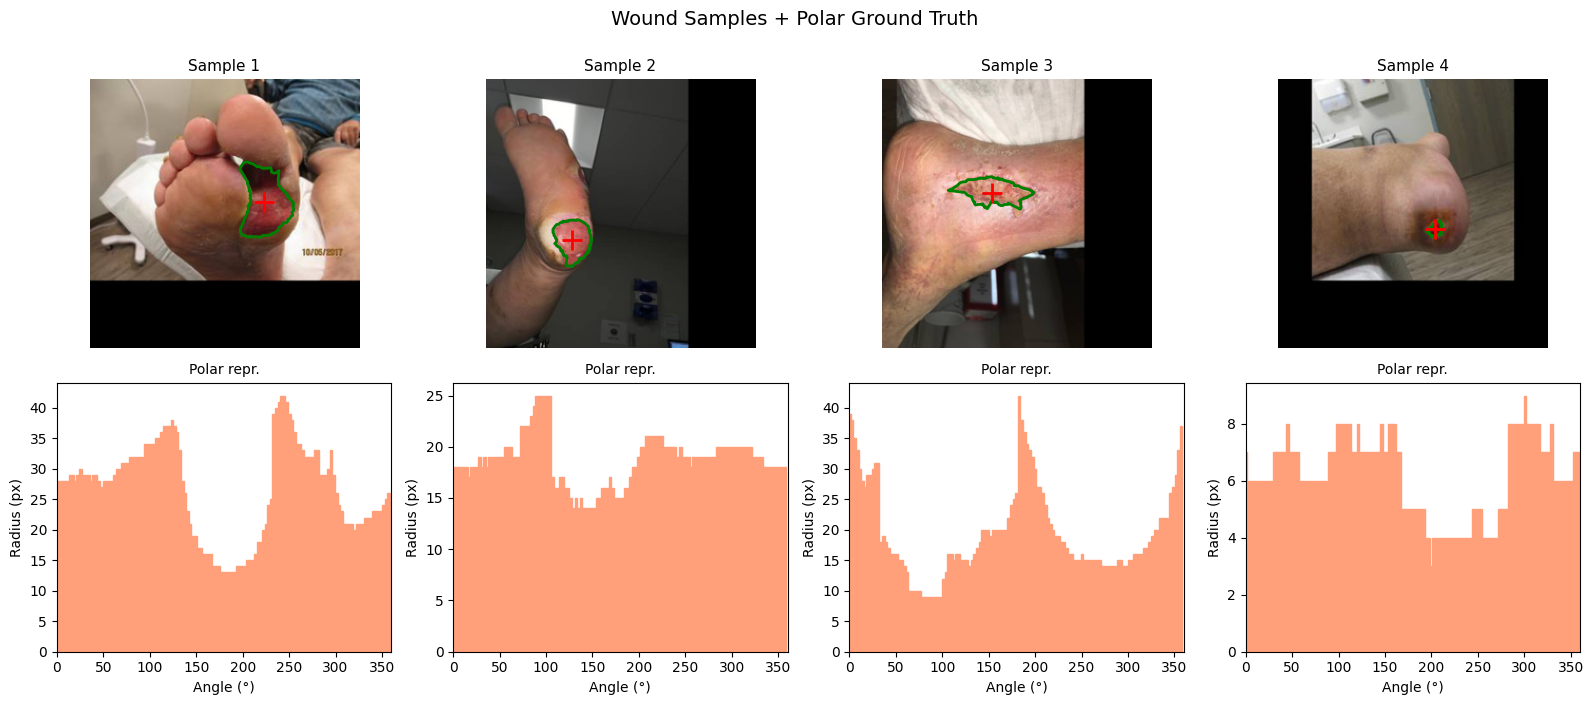

Shown 4 samples from: ['FUSeg', 'FUSeg', 'FUSeg', 'FUSeg']


In [6]:
# Visualize 4 real wound samples with their polar ground truth
_viz_samples = [s for s in train_ds.valid_samples if s['ds_name'] != 'synthetic'][:4]
if not _viz_samples:
    _viz_samples = train_ds.valid_samples[:4]

n_viz = len(_viz_samples)
fig, axes = plt.subplots(2, n_viz, figsize=(4*n_viz, 7))
if n_viz == 1:
    axes = axes.reshape(2, 1)

for i, sample in enumerate(_viz_samples):
    img = np.array(Image.open(sample['img_path']).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE)))
    label = sample['label']
    cx, cy = label['centroid'][0] * IMAGE_SIZE, label['centroid'][1] * IMAGE_SIZE
    pts = label['points'] * IMAGE_SIZE

    ax = axes[0, i]
    ax.imshow(img)
    ax.plot(np.append(pts[:,0], pts[0,0]), np.append(pts[:,1], pts[0,1]), 'g-', lw=2)
    ax.plot(cx, cy, 'r+', markersize=14, markeredgewidth=2)
    ax.set_title(f"Sample {i+1}", fontsize=11)
    ax.axis('off')

    ax2 = axes[1, i]
    angles_deg = np.linspace(0, 360, NUM_RADII, endpoint=False)
    radii_px = label['radii'] * max(IMAGE_SIZE, IMAGE_SIZE)
    ax2.bar(angles_deg, radii_px, width=360/NUM_RADII, color='lightsalmon', edgecolor='lightsalmon')
    ax2.set_xlabel('Angle (\u00b0)')
    ax2.set_ylabel('Radius (px)')
    ax2.set_title('Polar repr.', fontsize=10)
    ax2.set_xlim(0, 360)

plt.suptitle('Wound Samples + Polar Ground Truth', fontsize=14, y=1.0)
plt.tight_layout()
plt.savefig('figures/polar_v2/data_quality_polar_gt.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Shown {n_viz} samples from: {[s["ds_name"] for s in _viz_samples]}')

## 2. Model

In [7]:
class CNNTransformerEncoder(nn.Module):
    def __init__(self, d_model=D_MODEL, nhead=8, num_layers=2, pretrained=True, dropout=0.1):
        super().__init__()
        backbone = models.resnet50(weights='DEFAULT' if pretrained else None)
        self.backbone = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3)
        self.proj = nn.Conv2d(1024, d_model, 1)
        self.pos_embed = nn.Parameter(torch.randn(1, 256, d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.d_model = d_model

    def forward(self, x):
        feat = self.proj(self.backbone(x))
        B, C, H, W = feat.shape
        tokens = feat.flatten(2).transpose(1,2)
        tokens = tokens + self.pos_embed[:, :tokens.size(1)]
        return self.transformer(tokens)


class PerAngleAttentionDecoder(nn.Module):
    """Each radius gets its own query attending to spatial features."""
    def __init__(self, d_model=D_MODEL, nhead=8, num_radii=NUM_RADII, num_layers=2):
        super().__init__()
        self.num_radii = num_radii
        self.queries = nn.Parameter(torch.randn(1, num_radii + 1, d_model) * 0.02)
        angles = torch.arange(num_radii).float() * (2 * math.pi / num_radii)
        ang_enc = torch.stack([angles.cos(), angles.sin()], dim=-1)
        ang_enc_full = torch.zeros(num_radii + 1, d_model)
        ang_enc_full[:num_radii, :2] = ang_enc
        self.register_buffer('ang_encoding', ang_enc_full.unsqueeze(0))
        dec_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.cross_attn = nn.TransformerDecoder(dec_layer, num_layers=num_layers)
        self.centroid_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, 2))
        self.radii_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, 1))
        self._angles = nn.Parameter(torch.arange(num_radii).float() * (2*math.pi/num_radii), requires_grad=False)

    def forward(self, memory):
        B = memory.size(0)
        q = (self.queries + self.ang_encoding).expand(B, -1, -1)
        out = self.cross_attn(q, memory)
        cx_cy = torch.sigmoid(self.centroid_head(out[:, -1]))
        r = torch.sigmoid(self.radii_head(out[:, :-1])).squeeze(-1) * 0.7
        ang = self._angles.unsqueeze(0)
        px = cx_cy[:, 0:1] + r * torch.cos(ang)
        py = cx_cy[:, 1:2] + r * torch.sin(ang)
        pts = torch.stack([px, py], dim=-1)
        return {'centroid': cx_cy, 'radii': r, 'points': pts}


class FourierDescriptorHead(nn.Module):
    """Auxiliary: predicts Fourier coefficients for smoothness regularization."""
    def __init__(self, d_model=D_MODEL, n_coeffs=32, num_radii=NUM_RADII):
        super().__init__()
        self.n_coeffs = n_coeffs
        self.head = nn.Sequential(nn.Linear(d_model, 256), nn.ReLU(), nn.Dropout(0.1),
                                  nn.Linear(256, 2 * n_coeffs))
        t = torch.arange(num_radii).float() * (2 * math.pi / num_radii)
        k = torch.arange(n_coeffs).float()
        self.register_buffer('cos_basis', torch.cos(t.unsqueeze(1) * k.unsqueeze(0)))
        self.register_buffer('sin_basis', torch.sin(t.unsqueeze(1) * k.unsqueeze(0)))

    def forward(self, global_feat):
        coeffs = self.head(global_feat)
        a, b = coeffs[:, :self.n_coeffs], coeffs[:, self.n_coeffs:]
        radii = torch.sigmoid(a @ self.cos_basis.T + b @ self.sin_basis.T) * 0.7
        return radii


class PolarModelV2(nn.Module):
    """Clean model: Encoder + Per-Angle Attention + Fourier regularizer."""
    def __init__(self, d_model=D_MODEL, num_radii=NUM_RADII, pretrained=True):
        super().__init__()
        self.encoder = CNNTransformerEncoder(d_model=d_model, pretrained=pretrained)
        self.decoder = PerAngleAttentionDecoder(d_model=d_model, num_radii=num_radii)
        self.fourier_head = FourierDescriptorHead(d_model=d_model, n_coeffs=32, num_radii=num_radii)

    def forward(self, x):
        memory = self.encoder(x)
        polar_out = self.decoder(memory)
        global_feat = memory.mean(dim=1)
        fourier_radii = self.fourier_head(global_feat)
        return {**polar_out, 'fourier_radii': fourier_radii}

with torch.no_grad():
    m = PolarModelV2(pretrained=False)
    o = m(torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE))
    print(f'Output: points={o["points"].shape}, radii={o["radii"].shape}, fourier={o["fourier_radii"].shape}')
    del m
print('PolarModelV2 OK.')

Output: points=torch.Size([2, 128, 2]), radii=torch.Size([2, 128]), fourier=torch.Size([2, 128])
PolarModelV2 OK.


## 3. Loss & Training

In [8]:
def combined_loss(pred, batch):
    """Simple, stable loss: MSE on polar targets + Fourier smoothness."""
    L_centroid = F.mse_loss(pred['centroid'], batch['centroid'])
    L_radii = F.mse_loss(pred['radii'], batch['radii'])
    L_points = F.mse_loss(pred['points'], batch['points'])
    L_fourier = F.mse_loss(pred['fourier_radii'], pred['radii'].detach())
    total = 1.0 * L_centroid + 1.5 * L_radii + 2.0 * L_points + 0.2 * L_fourier
    return total, {'centroid': L_centroid.item(), 'radii': L_radii.item(),
                   'points': L_points.item(), 'fourier': L_fourier.item(), 'total': total.item()}

print('Loss defined.')

Loss defined.


In [9]:
from torch.cuda.amp import autocast, GradScaler

def train_model(model, train_dl, val_dl, max_epochs=MAX_EPOCHS, lr=LR):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    scaler = GradScaler()
    best_val = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    for epoch in range(max_epochs):
        model.train()
        train_losses = []
        for batch in tqdm(train_dl, desc=f'Ep {epoch+1}/{max_epochs}', leave=False):
            images = batch['image'].to(device)
            batch_gpu = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
            optimizer.zero_grad()
            with autocast():
                pred = model(images)
                loss, ld = combined_loss(pred, batch_gpu)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_losses.append(ld['total'])

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch in val_dl:
                images = batch['image'].to(device)
                batch_gpu = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
                with autocast():
                    pred = model(images)
                    loss, ld = combined_loss(pred, batch_gpu)
                val_losses.append(ld['total'])

        scheduler.step()
        avg_t, avg_v = np.mean(train_losses), np.mean(val_losses)
        history['train_loss'].append(avg_t)
        history['val_loss'].append(avg_v)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        print(f'  Ep {epoch+1:3d} | train={avg_t:.4f} val={avg_v:.4f} lr={history["lr"][-1]:.2e}')

        if avg_v < best_val:
            best_val = avg_v
            torch.save({'epoch': epoch+1, 'model_state': model.state_dict(),
                        'best_val': best_val, 'history': history}, 'results/polar_v2/best.pth')

    ckpt = torch.load('results/polar_v2/best.pth', weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    print(f'Best model: epoch {ckpt["epoch"]}, val={ckpt["best_val"]:.4f}')
    return model, history

model = PolarModelV2(pretrained=True)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
model, history = train_model(model, train_dl, val_dl)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


Parameters: 12,739,203


  Ep   1 | train=0.0393 val=0.0113 lr=9.99e-05


  Ep   2 | train=0.0115 val=0.0103 lr=9.96e-05


...

  Ep  46 | train=0.0021 val=0.0026 lr=1.57e-06


  Ep  47 | train=0.0021 val=0.0026 lr=8.86e-07


  Ep  48 | train=0.0025 val=0.0026 lr=3.94e-07


  Ep  49 | train=0.0022 val=0.0029 lr=9.87e-08


  Ep  50 | train=0.0026 val=0.0026 lr=0.00e+00
Best model: epoch 47, val=0.0026


## 4. Evaluation

In [10]:
def evaluate_model(model, test_dl):
    model.eval()
    all_ious_mask, all_ious_polar, all_chamfers, all_preds = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(test_dl, desc='Evaluating'):
            images = batch['image'].to(device)
            with autocast():
                pred = model(images)
            pred_pts = pred['points'].cpu()
            gt_pts = batch['points']
            for j in range(len(pred_pts)):
                pp = (pred_pts[j].numpy() * IMAGE_SIZE).astype(np.int32)
                gp = (gt_pts[j].numpy() * IMAGE_SIZE).astype(np.int32)
                pm = np.zeros((IMAGE_SIZE, IMAGE_SIZE), np.uint8)
                gm = np.zeros((IMAGE_SIZE, IMAGE_SIZE), np.uint8)
                cv2.fillPoly(pm, [pp], 1); cv2.fillPoly(gm, [gp], 1)
                inter = float((pm & gm).sum()); union = float((pm | gm).sum())
                all_ious_polar.append(inter/union if union > 0 else 0)
                # IoU vs raw mask
                rm = (batch['raw_mask'][j].numpy() > 0.5).astype(np.uint8)
                if rm.max() > 0:
                    inter_m = float((pm & rm).sum()); union_m = float((pm | rm).sum())
                    all_ious_mask.append(inter_m/union_m if union_m > 0 else 0)
                # Chamfer
                pp_f = pred_pts[j].numpy()*IMAGE_SIZE; gp_f = gt_pts[j].numpy()*IMAGE_SIZE
                d1 = np.min(np.linalg.norm(pp_f[:,None]-gp_f[None,:], axis=-1), axis=1).mean()
                d2 = np.min(np.linalg.norm(gp_f[:,None]-pp_f[None,:], axis=-1), axis=1).mean()
                all_chamfers.append((d1+d2)/2)
                all_preds.append({'pred_pts': pred_pts[j].numpy(), 'gt_pts': gt_pts[j].numpy(),
                    'ds_name': batch['ds_name'][j], 'image': batch['image'][j],
                    'raw_mask': batch['raw_mask'][j].numpy()})

    results = {
        'iou_vs_mask': {'mean': float(np.mean(all_ious_mask)) if all_ious_mask else 0.0,
                        'std': float(np.std(all_ious_mask)) if all_ious_mask else 0.0},
        'iou_vs_polar_gt': {'mean': float(np.mean(all_ious_polar)), 'std': float(np.std(all_ious_polar))},
        'chamfer_px': {'mean': float(np.mean(all_chamfers)), 'std': float(np.std(all_chamfers))},
        'n_samples': len(all_chamfers)}
    print(f'\n=== Results (n={results["n_samples"]}) ===')
    print(f'  IoU vs RAW MASK: {results["iou_vs_mask"]["mean"]:.4f} +/- {results["iou_vs_mask"]["std"]:.4f}')
    print(f'  IoU vs polar GT: {results["iou_vs_polar_gt"]["mean"]:.4f} +/- {results["iou_vs_polar_gt"]["std"]:.4f}')
    print(f'  Chamfer (px):    {results["chamfer_px"]["mean"]:.2f} +/- {results["chamfer_px"]["std"]:.2f}')
    with open('results/polar_v2/metrics.json', 'w') as f:
        json.dump(results, f, indent=2)
    return results, all_preds

results, all_preds = evaluate_model(model, test_dl)

Evaluating: 100%|██████████| 44/44 [00:01<00:00, 22.29it/s]


=== Results (n=264) ===
  IoU vs RAW MASK: 0.6479 +/- 0.1614
  IoU vs polar GT: 0.6723 +/- 0.1541
  Chamfer (px):    3.59 +/- 1.83


## 5. Qualitative Results

Datasets: ['Medetec', 'AZH'] | Selected: 4 samples


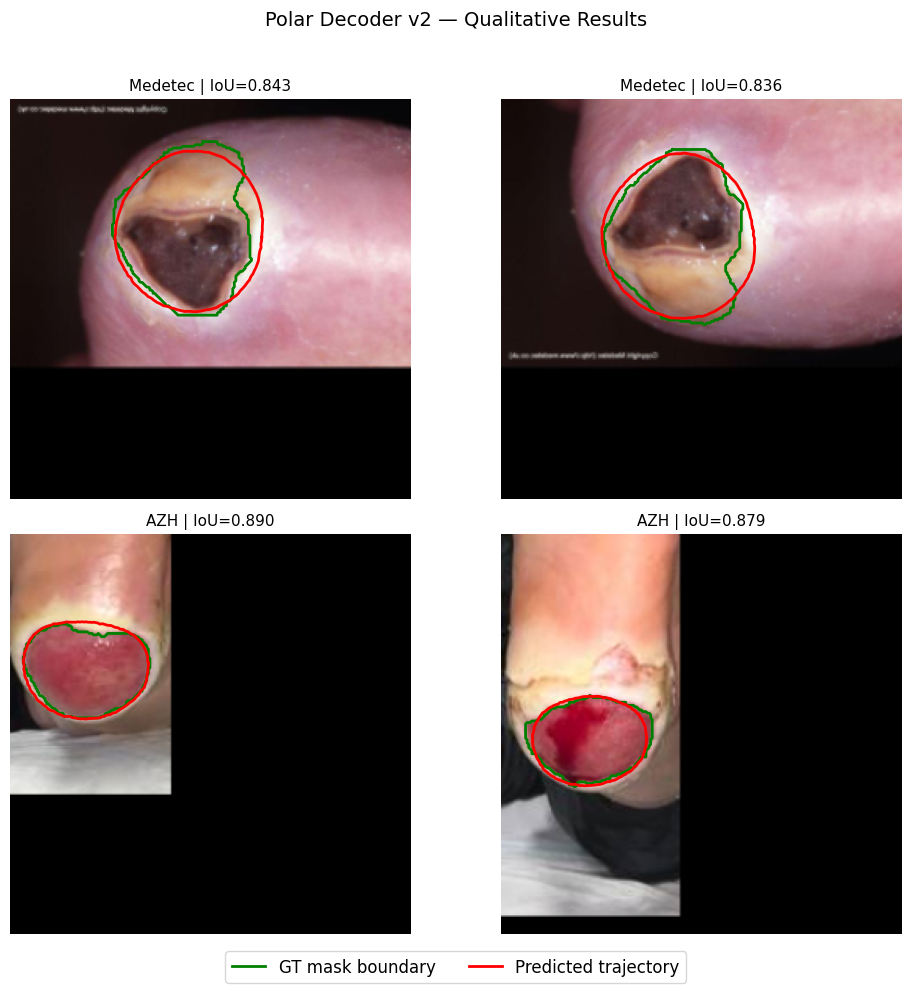

In [11]:
MEAN_T = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
STD_T  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
def denormalize(img_t): return (img_t * STD_T + MEAN_T).clamp(0,1).permute(1,2,0).numpy()

# Group by dataset, skip synthetic
preds_by_ds = {}
for p in all_preds:
    if p['ds_name'] == 'synthetic': continue
    preds_by_ds.setdefault(p['ds_name'], []).append(p)

# Select top-2 per dataset by IoU vs mask
selected = []
for ds_name, preds in preds_by_ds.items():
    scored = []
    for p in preds:
        pp = (p['pred_pts'] * IMAGE_SIZE).astype(np.int32)
        pm = np.zeros((IMAGE_SIZE, IMAGE_SIZE), np.uint8)
        cv2.fillPoly(pm, [pp], 1)
        gt = (p['raw_mask'] > 0.5).astype(np.uint8)
        inter = (pm & gt).sum(); union = (pm | gt).sum()
        iou = inter/union if union > 0 else 0
        scored.append((iou, p))
    scored.sort(key=lambda x: x[0], reverse=True)
    for iou, p in scored[:2]:
        p['iou'] = iou; p['dataset'] = ds_name
        selected.append(p)

print(f'Datasets: {list(preds_by_ds.keys())} | Selected: {len(selected)} samples')

# 2x2 grid
n = min(len(selected), 4)
cols = 2
rows = (n + 1) // 2
fig, axes = plt.subplots(rows, cols, figsize=(10, 5*rows))
axes = axes.flatten() if n > 1 else [axes]

for i, sample in enumerate(selected[:n]):
    ax = axes[i]
    ax.imshow(denormalize(sample['image']))
    mask = (sample['raw_mask'] > 0.5).astype(np.uint8)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        pts = cnt.squeeze()
        if len(pts.shape) == 2 and len(pts) > 2:
            ax.plot(np.append(pts[:,0], pts[0,0]), np.append(pts[:,1], pts[0,1]),
                    'g-', linewidth=2, label='GT mask' if i==0 else '')
    pred_px = sample['pred_pts'] * IMAGE_SIZE
    ax.plot(np.append(pred_px[:,0], pred_px[0,0]), np.append(pred_px[:,1], pred_px[0,1]),
            'r-', linewidth=2, label='Prediction' if i==0 else '')
    ax.set_title(f"{sample['dataset']} | IoU={sample['iou']:.3f}", fontsize=11)
    ax.axis('off')

for i in range(n, len(axes)): axes[i].set_visible(False)
fig.legend(['GT mask boundary', 'Predicted trajectory'], loc='lower center', ncol=2, fontsize=12)
plt.suptitle('Polar Decoder v2 — Qualitative Results', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig('figures/polar_v2/qualitative_per_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

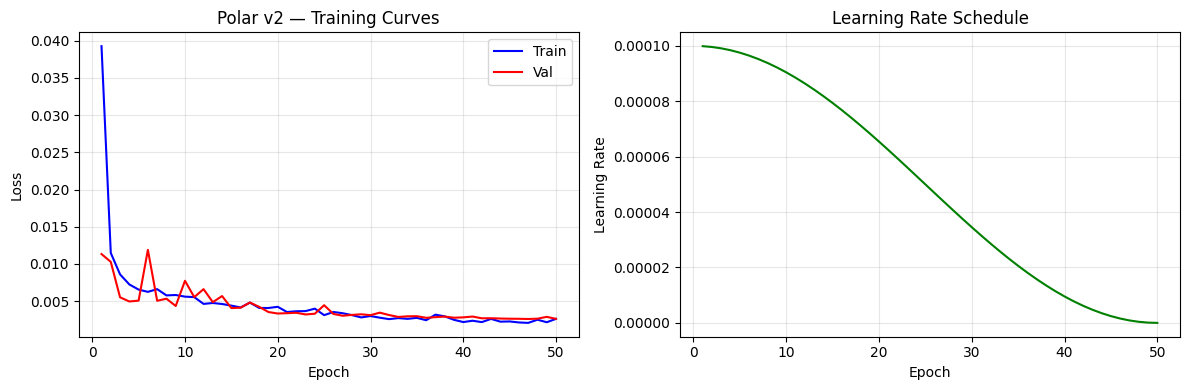

In [12]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history['train_loss'])+1)
ax1.plot(epochs, history['train_loss'], 'b-', label='Train')
ax1.plot(epochs, history['val_loss'], 'r-', label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Polar v2 — Training Curves'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(epochs, history['lr'], 'g-')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate Schedule'); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/polar_v2/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [13]:
print('\n' + '='*60)
print('POLAR DECODER v2 — FINAL SUMMARY')
print('='*60)
print(f'Architecture:  ResNet-50 + Transformer + Per-Angle Attention')
print(f'Radii:         {NUM_RADII}')
print(f'Regularizer:   Fourier descriptor (32 coefficients)')
print(f'Loss:          MSE (centroid + radii + points) + Fourier consistency')
print(f'Sigmoid range: [0, 0.7]')
print('-'*60)
print(f'IoU vs raw mask:  {results["iou_vs_mask"]["mean"]:.4f} +/- {results["iou_vs_mask"]["std"]:.4f}')
print(f'IoU vs polar GT:  {results["iou_vs_polar_gt"]["mean"]:.4f} +/- {results["iou_vs_polar_gt"]["std"]:.4f}')
print(f'Chamfer (px):     {results["chamfer_px"]["mean"]:.2f} +/- {results["chamfer_px"]["std"]:.2f}')
print(f'Test samples:     {results["n_samples"]}')
print('='*60)
print('\nOutput files:')
print('  results/polar_v2/best.pth')
print('  results/polar_v2/metrics.json')
print('  figures/polar_v2/qualitative_per_dataset.png')
print('  figures/polar_v2/training_curves.png')


POLAR DECODER v2 — FINAL SUMMARY
Architecture:  ResNet-50 + Transformer + Per-Angle Attention
Radii:         128
Regularizer:   Fourier descriptor (32 coefficients)
Loss:          MSE (centroid + radii + points) + Fourier consistency
Sigmoid range: [0, 0.7]
------------------------------------------------------------
IoU vs raw mask:  0.6479 +/- 0.1614
IoU vs polar GT:  0.6723 +/- 0.1541
Chamfer (px):     3.59 +/- 1.83
Test samples:     264

Output files:
  results/polar_v2/best.pth
  results/polar_v2/metrics.json
  figures/polar_v2/qualitative_per_dataset.png
  figures/polar_v2/training_curves.png
